In [1]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report

In [2]:
df=pd.read_csv(r"C:\Users\RESHMA\Downloads\ML Session 9\cashless_claim_prediction_dataset (1).csv")
df

,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,NaN,0.0,1,...,3915.0,10,10000,0,50974,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824,30179,8293,10292,61.0,48351
3,CLM00004997,PAT001322,HSP0077,2023-06-28,6,Male,1.0,NaN,0.0,2,...,2201.0,0,1000,0,59420,20321,8625,18688,64.0,35995
4,CLM00001759,PAT001541,HSP0114,2025-01-12,58,Male,1.0,23.1,0.0,2,...,1500.0,20,30000,0,105636,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CLM00001444,PAT000312,HSP0060,2024-02-28,33,Male,1.0,31.1,0.0,1,...,3812.0,5,10000,0,44763,15723,6485,9841,52.0,19385
4996,CLM00003506,PAT000082,HSP0017,2023-10-04,28,Female,1.0,25.7,0.0,3,...,1500.0,30,2000,0,63330,22358,15588,13009,74.0,25669
4997,CLM00003374,PAT000823,HSP0164,2023-11-21,64,Male,1.0,24.1,0.0,3,...,1500.0,10,2000,0,122105,55007,25200,28427,55.0,72412
4998,CLM00003850,PAT001755,HSP0197,2024-01-17,36,Male,1.0,27.4,0.0,2,...,1500.0,30,30000,0,115131,46046,27583,23221,72.0,25870


In [3]:
df.columns

Index(['claim_id', 'patient_id', 'hospital_id', 'claim_submitted_date', 'age',
       'gender', 'city_tier', 'bmi', 'smoker_flag', 'comorbidity_score',
       'prior_claim_count_2yr', 'prior_claim_amount_2yr', 'admission_type',
       'treatment_type', 'diagnosis_category', 'severity_level',
       'procedure_count', 'procedure_complexity_score', 'icu_days',
       'length_of_stay_days', 'pre_existing_disease_flag', 'hospital_type',
       'hospital_tier', 'network_hospital_flag',
       'hospital_historical_approval_rate', 'hospital_billing_index',
       'hospital_city_tier', 'policy_type', 'policy_tenure_months',
       'sum_insured', 'remaining_sum_insured', 'room_rent_limit_per_day',
       'copay_percent', 'deductible_amount', 'waiting_period_applicable_flag',
       'claimed_amount', 'room_charges', 'doctor_fees', 'medicine_charges',
       'document_quality_score', 'approved_amount'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   claim_id                           5000 non-null   object 
 1   patient_id                         5000 non-null   object 
 2   hospital_id                        5000 non-null   object 
 3   claim_submitted_date               5000 non-null   object 
 4   age                                5000 non-null   int64  
 5   gender                             5000 non-null   object 
 6   city_tier                          4951 non-null   float64
 7   bmi                                4779 non-null   float64
 8   smoker_flag                        4876 non-null   float64
 9   comorbidity_score                  5000 non-null   int64  
 10  prior_claim_count_2yr              5000 non-null   int64  
 11  prior_claim_amount_2yr             5000 non-null   int64

In [5]:
df.describe()

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
count,5000.000000,4951.000000,4779.000000,4876.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,...,4926.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,4826.000000,5000.000000
mean,41.820000,1.899414,25.078301,0.174733,1.682200,0.668800,15437.033400,3.207200,1.464000,5.00402,...,3492.293138,8.664000,9573.000000,0.139000,60946.41620,23749.421400,11716.619400,12860.567000,71.633651,26672.628800
std,19.659301,0.808029,5.374184,0.379778,1.362341,0.803266,25447.022739,1.237972,1.296395,2.06884,...,2993.455149,10.688683,12551.022932,0.345981,31158.88568,13849.105071,7302.144875,7181.197583,15.470435,19632.937744
min,0.000000,1.000000,-3.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,...,1500.000000,0.000000,0.000000,0.000000,-5000.00000,2155.000000,1139.000000,1250.000000,2.000000,0.000000
25%,30.000000,1.000000,22.100000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,3.50000,...,1500.000000,0.000000,0.000000,0.000000,38742.25000,13990.500000,6385.750000,7831.250000,61.000000,12910.000000
50%,43.000000,2.000000,25.000000,0.000000,1.000000,0.000000,0.000000,3.000000,1.000000,4.90000,...,2029.000000,5.000000,5000.000000,0.000000,54791.00000,20452.000000,9811.000000,11316.500000,72.000000,23958.000000
75%,54.000000,3.000000,27.900000,0.000000,2.000000,1.000000,22149.250000,4.000000,2.000000,6.50000,...,4351.500000,15.000000,15000.000000,0.000000,76792.25000,30449.750000,15263.250000,16184.750000,83.000000,36986.750000
max,150.000000,3.000000,80.000000,1.000000,8.000000,5.000000,336714.000000,5.000000,8.000000,10.00000,...,20346.000000,120.000000,50000.000000,1.000000,259083.00000,113520.000000,60466.000000,79411.000000,100.000000,153439.000000


In [6]:
df.loc[df["bmi"] <= 0, "bmi"] = np.nan


In [7]:
df["bmi"].fillna(df["bmi"].median(), inplace=True)


In [8]:
df.loc[df["claimed_amount"] <= 0, "claimed_amount"] = np.nan

In [9]:
df["claimed_amount"].fillna(df["claimed_amount"].median(), inplace=True)


In [10]:
df.describe()

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
count,5000.000000,4951.000000,5000.000000,4876.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,...,4926.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4826.000000,5000.000000
mean,41.820000,1.899414,25.160440,0.174733,1.682200,0.668800,15437.033400,3.207200,1.464000,5.00402,...,3492.293138,8.664000,9573.000000,0.139000,61176.074200,23749.421400,11716.619400,12860.567000,71.633651,26672.628800
std,19.659301,0.808029,5.028427,0.379778,1.362341,0.803266,25447.022739,1.237972,1.296395,2.06884,...,2993.455149,10.688683,12551.022932,0.345981,30900.468471,13849.105071,7302.144875,7181.197583,15.470435,19632.937744
min,0.000000,1.000000,13.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,...,1500.000000,0.000000,0.000000,0.000000,6734.000000,2155.000000,1139.000000,1250.000000,2.000000,0.000000
25%,30.000000,1.000000,22.300000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,3.50000,...,1500.000000,0.000000,0.000000,0.000000,38988.750000,13990.500000,6385.750000,7831.250000,61.000000,12910.000000
50%,43.000000,2.000000,25.000000,0.000000,1.000000,0.000000,0.000000,3.000000,1.000000,4.90000,...,2029.000000,5.000000,5000.000000,0.000000,54914.500000,20452.000000,9811.000000,11316.500000,72.000000,23958.000000
75%,54.000000,3.000000,27.800000,0.000000,2.000000,1.000000,22149.250000,4.000000,2.000000,6.50000,...,4351.500000,15.000000,15000.000000,0.000000,76792.250000,30449.750000,15263.250000,16184.750000,83.000000,36986.750000
max,150.000000,3.000000,80.000000,1.000000,8.000000,5.000000,336714.000000,5.000000,8.000000,10.00000,...,20346.000000,120.000000,50000.000000,1.000000,259083.000000,113520.000000,60466.000000,79411.000000,100.000000,153439.000000


In [11]:
df.isnull().sum()

claim_id                               0
patient_id                             0
hospital_id                            0
claim_submitted_date                   0
age                                    0
gender                                 0
city_tier                             49
bmi                                    0
smoker_flag                          124
comorbidity_score                      0
prior_claim_count_2yr                  0
prior_claim_amount_2yr                 0
admission_type                         0
treatment_type                         0
diagnosis_category                     0
severity_level                         0
procedure_count                        0
procedure_complexity_score             0
icu_days                               0
length_of_stay_days                    0
pre_existing_disease_flag              0
hospital_type                          0
hospital_tier                          0
network_hospital_flag                  0
hospital_histori

In [12]:
df["city_tier"].fillna(df["city_tier"].median(), inplace=True)
df["bmi"].fillna(df["bmi"].mean(), inplace=True)
df["smoker_flag"].fillna(df["smoker_flag"].median(), inplace=True)
df["hospital_billing_index"].fillna(df["hospital_billing_index"].mean(),inplace=True)
df["room_rent_limit_per_day"].fillna(df["room_rent_limit_per_day"].mean(),inplace=True)
df["document_quality_score"].fillna(df["document_quality_score"].mean(),inplace=True)

In [13]:
df.isnull().sum()

claim_id                             0
patient_id                           0
hospital_id                          0
claim_submitted_date                 0
age                                  0
gender                               0
city_tier                            0
bmi                                  0
smoker_flag                          0
comorbidity_score                    0
prior_claim_count_2yr                0
prior_claim_amount_2yr               0
admission_type                       0
treatment_type                       0
diagnosis_category                   0
severity_level                       0
procedure_count                      0
procedure_complexity_score           0
icu_days                             0
length_of_stay_days                  0
pre_existing_disease_flag            0
hospital_type                        0
hospital_tier                        0
network_hospital_flag                0
hospital_historical_approval_rate    0
hospital_billing_index   

In [14]:
df.duplicated().sum()

np.int64(96)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["gender"].value_counts()

gender
Male       2578
Female     2173
Other       105
F            17
Unknown      17
M            14
Name: count, dtype: int64

In [18]:
df["gender"]=df["gender"].replace({
    "F":"Female",
    "Unknown":"Other",
    "M":"Male"
})

In [19]:
df["gender"].value_counts()

gender
Male      2592
Female    2190
Other      122
Name: count, dtype: int64

In [20]:
df

,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,2024-08-24,62,Female,3.0,25.0,0.0,1,...,3915.0,10,10000,0,50974.0,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,2024-04-11,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113.0,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,2023-07-04,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824.0,30179,8293,10292,61.0,48351
3,CLM00004997,PAT001322,HSP0077,2023-06-28,6,Male,1.0,25.0,0.0,2,...,2201.0,0,1000,0,59420.0,20321,8625,18688,64.0,35995
4,CLM00001759,PAT001541,HSP0114,2025-01-12,58,Male,1.0,23.1,0.0,2,...,1500.0,20,30000,0,105636.0,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,CLM00003998,PAT000091,HSP0093,2025-06-16,57,Female,2.0,23.2,0.0,3,...,2046.0,10,30000,1,30725.0,8558,4846,5317,83.0,0
4995,CLM00001444,PAT000312,HSP0060,2024-02-28,33,Male,1.0,31.1,0.0,1,...,3812.0,5,10000,0,44763.0,15723,6485,9841,52.0,19385
4996,CLM00003506,PAT000082,HSP0017,2023-10-04,28,Female,1.0,25.7,0.0,3,...,1500.0,30,2000,0,63330.0,22358,15588,13009,74.0,25669
4997,CLM00003374,PAT000823,HSP0164,2023-11-21,64,Male,1.0,24.1,0.0,3,...,1500.0,10,2000,0,122105.0,55007,25200,28427,55.0,72412


In [21]:
df[df['age'] > 100]['age'].value_counts()

age
101    17
150    14
120     9
Name: count, dtype: int64

In [22]:
df.loc[df['age'] > 110, 'age'] = np.nan

In [23]:
df['age'] = df['age'].fillna(df['age'].median())

In [24]:
df[df['age'] > 100]['age'].value_counts()

age
101.0    17
Name: count, dtype: int64

In [25]:
df[df['age'] > 70]['age'].value_counts()

age
71.0     31
74.0     28
73.0     22
72.0     20
75.0     18
101.0    17
77.0     14
79.0     10
90.0      9
85.0      8
80.0      8
78.0      8
86.0      8
81.0      7
83.0      7
76.0      7
82.0      6
84.0      3
89.0      2
87.0      2
88.0      1
Name: count, dtype: int64

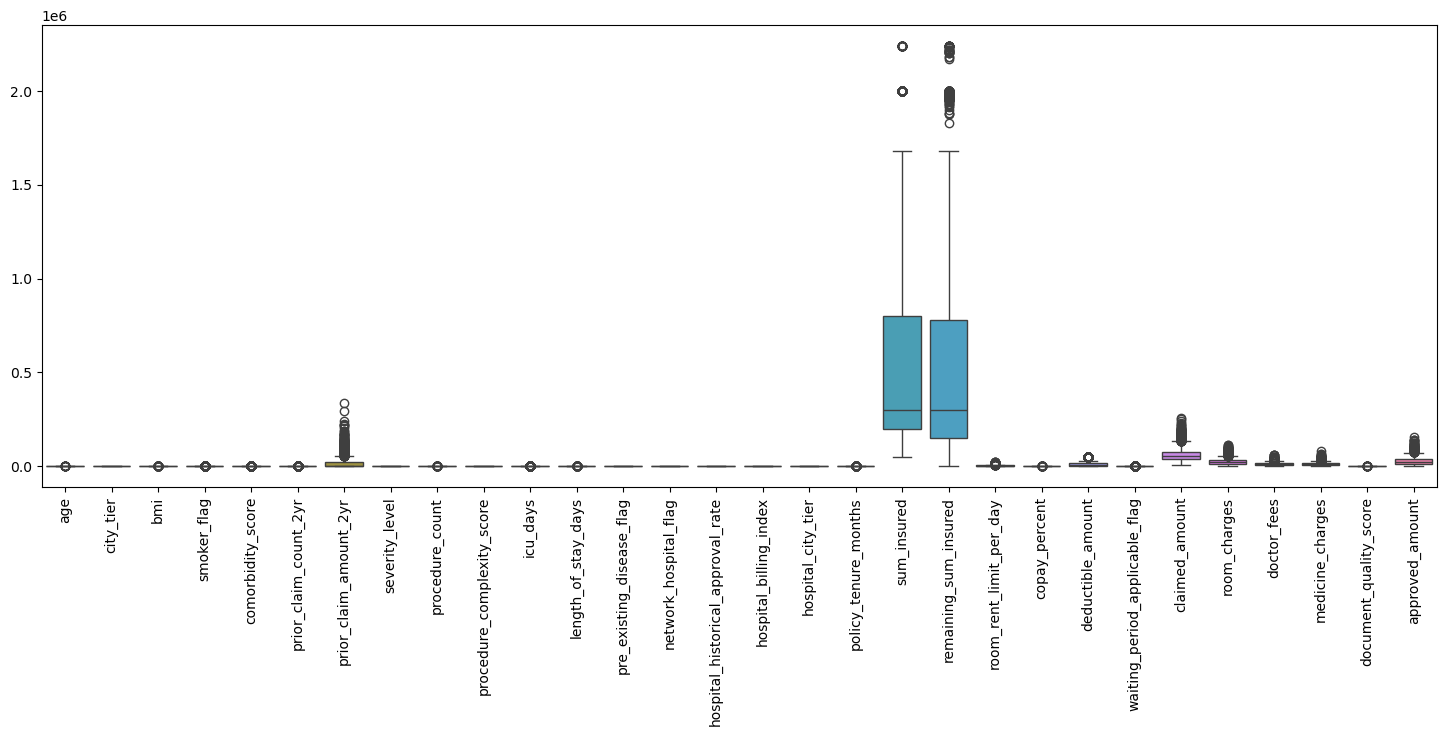

In [26]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df.select_dtypes(include="number"))
plt.xticks(rotation=90)
plt.show()

In [27]:
money_cols = [
    "prior_claim_amount_2yr",
    "sum_insured",
    "remaining_sum_insured",
    "room_rent_limit_per_day",
    "deductible_amount",
    "claimed_amount",
    "room_charges",
    "doctor_fees",
    "medicine_charges",
    "approved_amount"
]

# Apply sqrt transformation to money columns

for col in money_cols:
    df[col + "_sqrt"] = np.sqrt(df[col])

# Identify other numeric columns

num_cols = df.select_dtypes(include=np.number).columns.tolist()
other_num_cols = [c for c in num_cols if c not in money_cols]

# Use IQR method to filter outliers in other numeric columns

for col in other_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

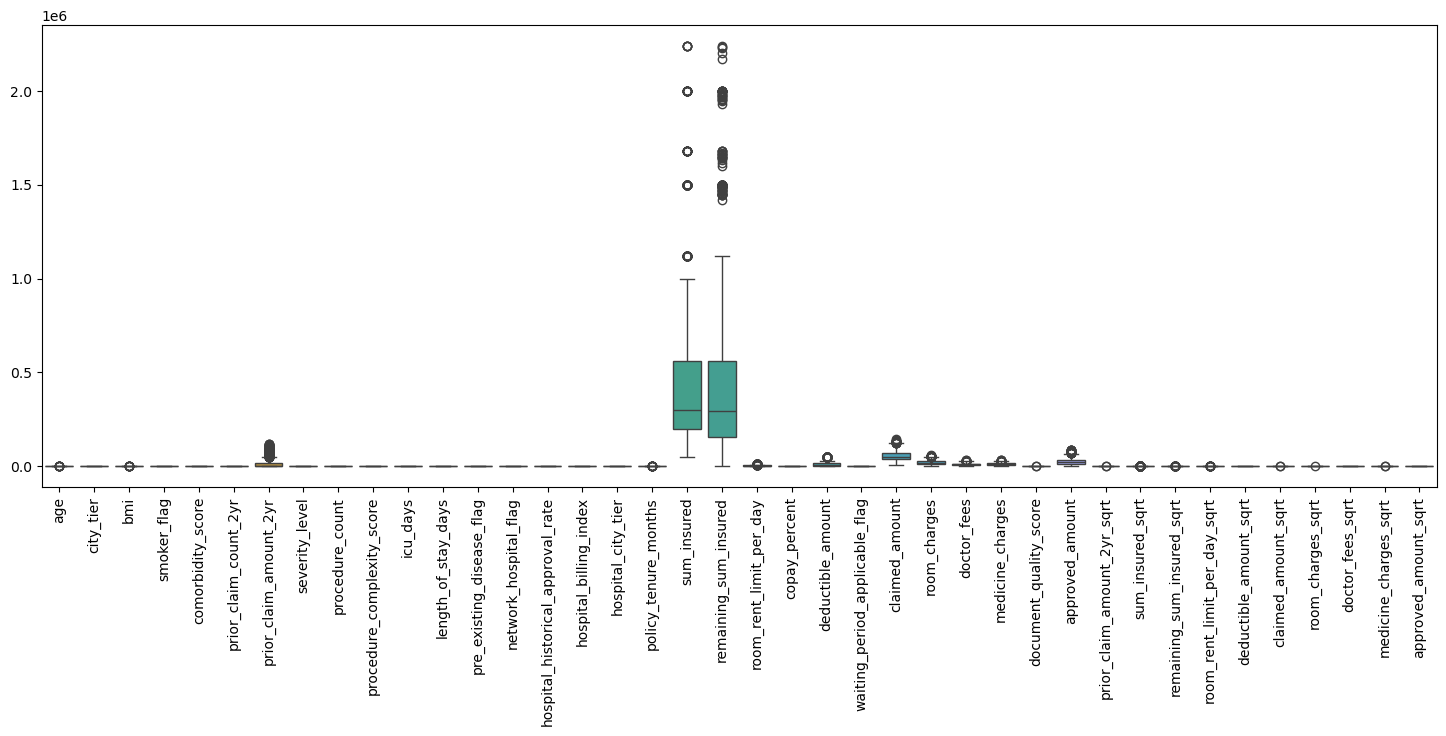

In [28]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df.select_dtypes(include="number"))
plt.xticks(rotation=90)
plt.show()

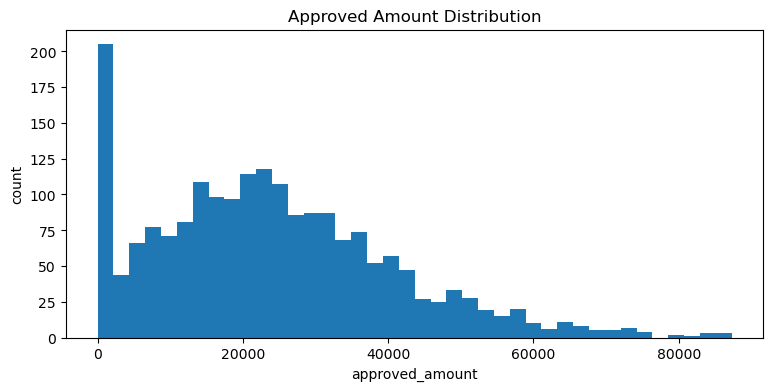

In [29]:
# EDA
# approved ammount

plt.figure(figsize=(9,4))
plt.hist(df['approved_amount'], bins=40)
plt.title('Approved Amount Distribution')
plt.xlabel('approved_amount')
plt.ylabel('count')
plt.show()

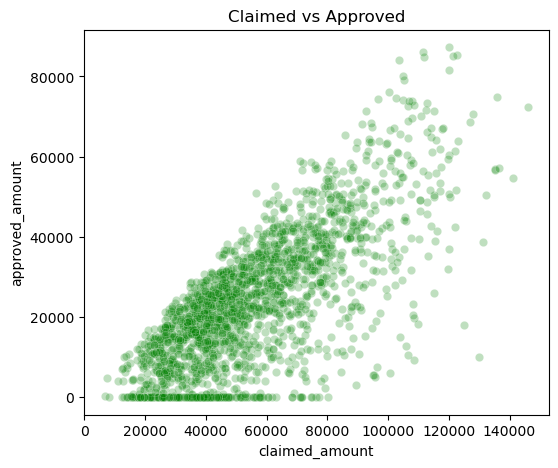

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="claimed_amount",
    y="approved_amount",
    alpha=0.25,
    color="green"
)
plt.title("Claimed vs Approved")
plt.show()


In [31]:
# severity level vs approved amount

severity_avg = df.groupby("severity_level")["approved_amount"].mean().reset_index()
severity_avg

,severity_level,approved_amount
0,1,19351.116883
1,2,22745.850962
2,3,22812.573379
3,4,27083.938053
4,5,26610.678082


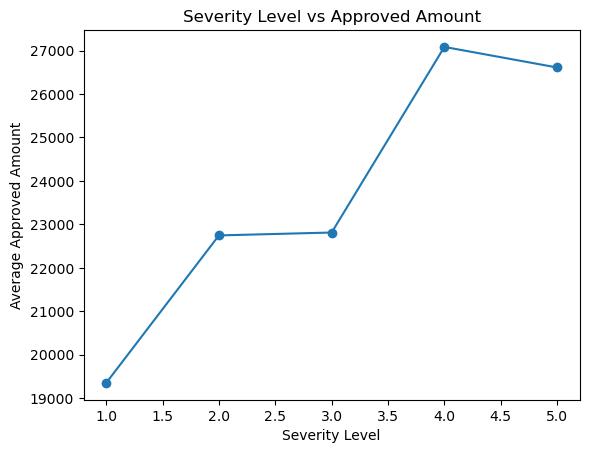

In [32]:
plt.figure()
plt.plot(severity_avg["severity_level"], 
         severity_avg["approved_amount"], marker='o')

plt.xlabel("Severity Level")
plt.ylabel("Average Approved Amount")
plt.title("Severity Level vs Approved Amount")
plt.show()


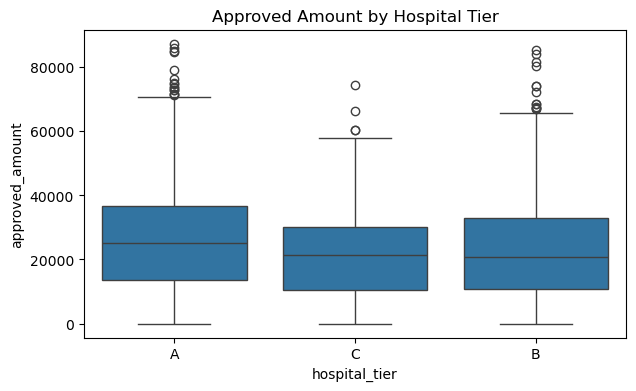

In [33]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="hospital_tier",
    y="approved_amount"
)
plt.title("Approved Amount by Hospital Tier")
plt.show()

In [34]:
df.columns

Index(['claim_id', 'patient_id', 'hospital_id', 'claim_submitted_date', 'age',
       'gender', 'city_tier', 'bmi', 'smoker_flag', 'comorbidity_score',
       'prior_claim_count_2yr', 'prior_claim_amount_2yr', 'admission_type',
       'treatment_type', 'diagnosis_category', 'severity_level',
       'procedure_count', 'procedure_complexity_score', 'icu_days',
       'length_of_stay_days', 'pre_existing_disease_flag', 'hospital_type',
       'hospital_tier', 'network_hospital_flag',
       'hospital_historical_approval_rate', 'hospital_billing_index',
       'hospital_city_tier', 'policy_type', 'policy_tenure_months',
       'sum_insured', 'remaining_sum_insured', 'room_rent_limit_per_day',
       'copay_percent', 'deductible_amount', 'waiting_period_applicable_flag',
       'claimed_amount', 'room_charges', 'doctor_fees', 'medicine_charges',
       'document_quality_score', 'approved_amount',
       'prior_claim_amount_2yr_sqrt', 'sum_insured_sqrt',
       'remaining_sum_insured_sqrt', 

In [35]:
df = df.drop(columns=["gender", "claim_id", "patient_id","hospital_id","claim_submitted_date"])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1977 entries, 0 to 4996
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                1977 non-null   float64
 1   city_tier                          1977 non-null   float64
 2   bmi                                1977 non-null   float64
 3   smoker_flag                        1977 non-null   float64
 4   comorbidity_score                  1977 non-null   int64  
 5   prior_claim_count_2yr              1977 non-null   int64  
 6   prior_claim_amount_2yr             1977 non-null   int64  
 7   admission_type                     1977 non-null   object 
 8   treatment_type                     1977 non-null   object 
 9   diagnosis_category                 1977 non-null   object 
 10  severity_level                     1977 non-null   int64  
 11  procedure_count                    1977 non-null   int64  
 1

In [37]:
x = df.drop(["approved_amount", "approved_amount_sqrt"], axis=1)
y = df["approved_amount"]

In [38]:
x = pd.get_dummies(x, drop_first=True,dtype=int)

In [39]:
x = x.astype(int)

In [40]:
x

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,diagnosis_category_Renal,diagnosis_category_Respiratory,diagnosis_category_Trauma,hospital_type_Govt,hospital_type_Trust,hospital_tier_B,hospital_tier_C,policy_type_Family,policy_type_Floater,policy_type_Individual
0,62,3,25,0,1,0,0,4,3,3,...,0,0,0,0,0,0,0,0,1,0
1,38,2,29,0,0,1,51576,4,5,3,...,0,0,0,0,0,0,1,1,0,0
3,6,1,25,0,2,0,0,4,3,5,...,0,0,0,0,0,0,0,0,0,0
5,64,2,30,0,2,2,23439,2,0,2,...,0,1,0,0,1,0,1,0,0,0
6,42,2,25,0,0,0,0,3,2,5,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4983,10,2,28,0,2,1,14356,2,0,6,...,0,0,0,0,0,0,1,0,0,0
4987,54,1,23,0,3,0,0,3,0,5,...,0,0,0,0,1,0,0,0,0,1
4989,31,3,18,0,0,0,0,1,3,2,...,0,0,0,0,0,1,0,0,1,0
4995,33,1,31,0,1,0,0,3,0,6,...,0,1,0,1,0,0,0,0,1,0


In [41]:
le = LabelEncoder()
y = le.fit_transform(y)

In [43]:
# Train–test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [44]:
cat_cols = x_train.select_dtypes(include="object").columns              # for leakage safe categorical

x_train = pd.get_dummies(x_train, columns=cat_cols, drop_first=True)
x_test  = pd.get_dummies(x_test,  columns=cat_cols, drop_first=True)

# Align columns
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)


In [48]:
#random forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Train R2:", rf.score(x_train, y_train))
print("Test R2:", rf.score(x_test, y_test))

MAE: 104.09554919109866
RMSE: 146.1719624923462
R2: 0.9277175920651041
Train R2: 0.9663333651844809
Test R2: 0.9277175920651041


In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=800,      # more trees
    max_depth=12,          # allow learning patterns
    min_samples_split=12,   # avoid tiny splits
    min_samples_leaf=5,    # prevent tiny leaves
    max_features=0.7,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

In [46]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [49]:
# Convert categorical columns to dummy variables
x_encoded = pd.get_dummies(x, drop_first=True)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x_encoded, y, cv=5, scoring="r2")

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())

CV Scores: [0.92786091 0.93876481 0.92264176 0.92609332 0.92044672]
Mean CV R2: 0.9271615046314142


In [51]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=700,   # slightly deeper than 5 to avoid severe underfitting
    min_samples_leaf=150,
    random_state=42
)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)


In [52]:
#decision tree

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)
print("Train R2:", dt.score(x_train, y_train))
print("Test R2:", dt.score(x_test, y_test))



Decision Tree Results:
MAE: 232.6230417124991
RMSE: 308.48575272162117
R2: 0.6780601937207491
Train R2: 0.7206871114926297
Test R2: 0.6780601937207491


In [53]:
# gradient

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(x_train, y_train)

y_pred_gbr = gbr.predict(x_test)

gbr

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [54]:
# evalute metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Results:")
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2:", r2_gbr)
print("Train R2:", gbr.score(x_train, y_train))
print("Test R2:", gbr.score(x_test, y_test))



Gradient Boosting Results:
MAE: 93.75185122307154
RMSE: 124.82309717434272
R2: 0.9472898363287362
Train R2: 0.9751960759654134
Test R2: 0.9472898363287362


In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gbr, x_encoded, y, cv=5, scoring="r2")

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())

CV Scores: [0.94989627 0.95857908 0.9490273  0.94643912 0.94501317]
Mean CV R2: 0.9497909876755392


In [57]:
# voting
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor([
    ('rf', rf),
    ('dt', dt),
    ('gbr', gbr)
])

voting.fit(x_train, y_train)

y_pred_v = voting.predict(x_test)

print("Voting R2:", r2_score(y_test, y_pred_v))

Voting R2: 0.8958053929706388


In [58]:
scores = cross_val_score(voting, x_encoded, y, cv=5, scoring="r2")
print("Voting CV Mean:", scores.mean())

Voting CV Mean: 0.901636523155943


In [59]:
#stacking

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

stack = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('dt', dt),
        ('gbr', gbr)
    ],
    final_estimator=LinearRegression()
)

stack.fit(x_train, y_train)

y_pred_s = stack.predict(x_test)

print("Stacking R2:", r2_score(y_test, y_pred_s))

Stacking R2: 0.9533187879757492


In [60]:
feature_importance = pd.Series(
    gbr.feature_importances_,
    index = x_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

claimed_amount                0.273585
deductible_amount             0.167728
deductible_amount_sqrt        0.145971
doctor_fees                   0.119468
room_charges                  0.109734
medicine_charges              0.038872
room_charges_sqrt             0.036914
remaining_sum_insured         0.029213
copay_percent                 0.019378
remaining_sum_insured_sqrt    0.018372
dtype: float64


In [61]:
mae_vote = mean_absolute_error(y_test, y_pred_v)
rmse_vote = np.sqrt(mean_squared_error(y_test, y_pred_v))
r2_vote = r2_score(y_test, y_pred_v)


In [62]:
mae_stack = mean_absolute_error(y_test, y_pred_s)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_s))
r2_stack = r2_score(y_test, y_pred_s)

In [63]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Voting Regressor",
        "Stacking Regressor"
    ],
    "MAE": [
        mae_dt,
        mae,
        mae_gbr,
        mae_vote,
        mae_stack
    ],
    "RMSE": [
        rmse_dt,
        rmse,
        rmse_gbr,
        rmse_vote,
        rmse_stack
    ],
    "R2": [
        r2_dt,
        r2,
        r2_gbr,
        r2_vote,
        r2_stack
    ]
})

print(comparison)



                Model         MAE        RMSE        R2
0       Decision Tree  232.623042  308.485753  0.678060
1       Random Forest  104.095549  146.171962  0.927718
2   Gradient Boosting   93.751851  124.823097  0.947290
3    Voting Regressor  132.803375  175.497281  0.895805
4  Stacking Regressor   87.981877  117.467800  0.953319


In [64]:
comparison = comparison.sort_values(by="R2", ascending=False)
print(comparison)

                Model         MAE        RMSE        R2
4  Stacking Regressor   87.981877  117.467800  0.953319
2   Gradient Boosting   93.751851  124.823097  0.947290
1       Random Forest  104.095549  146.171962  0.927718
3    Voting Regressor  132.803375  175.497281  0.895805
0       Decision Tree  232.623042  308.485753  0.678060


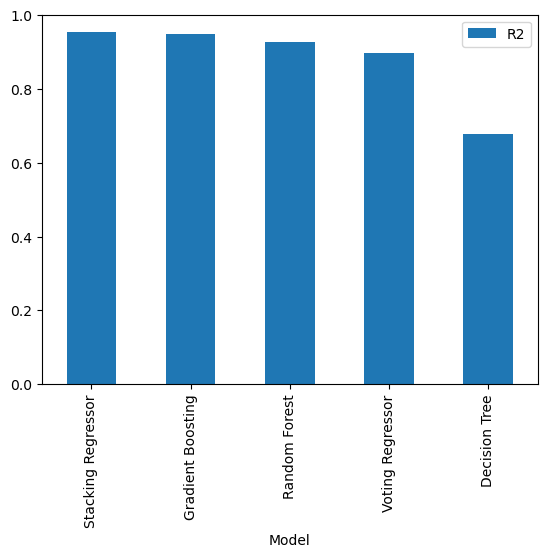

In [65]:
comparison.plot(x="Model", y="R2", kind="bar")
plt.show()

In [ ]:
# Interpretation

The models evaluated included Decision Tree, Random Forest, Gradient Boosting, Voting Regressor, and Stacking Regressor. 
Model performance was assessed using MAE, RMSE, and R² to ensure both accuracy and robustness.
Among all models tested, the Stacking Regressor performed best, achieving the lowest MAE and RMSE and the highest R² of 0.953. 
This means it explains about 95% of the variance in the target variable and provides the most accurate predictions.
Therefore, the Stacking Regressor was selected as the final model for predicting approved loan amounts.